# Embedding generation
---
1. Knowledge graph generation
2. Edges train-validation-test split
3. Node embeddings generation on training edges with node2vec
4. Edge embeddings generation by taking the Hadamard product of node embeddings
5. Cross-validation by link prediction task on validation and test edges with loggistic regression
6. Node embeddings generation with tuned hyper-parameters on all edges with node2vec

## 1. Knowledge graph generation
---
hpo ontology
https://raw.githubusercontent.com/obophenotype/human-phenotype-ontology/master/hp.obo

gene-phenotype annotations
http://compbio.charite.de/jenkins/job/hpo.annotations/lastSuccessfulBuild/artifact/util/annotation/genes_to_phenotype.txt


In [31]:
import os
import pandas as pd
from CADA.triples_gene_hpo import triples_gene_hpo
from CADA.triples_patients import triples_patients
from CADA.triples_hierarchical_hpo import triples_hierarchical_hpo
from CADA.split import split
from CADA.train_partition import train_partition

In [32]:
# get a list of triple of nodes and relationships between them
triples = []

hpo_triples = triples_hierarchical_hpo() # triples of hpo-hpo hierarchical relationships from hpo ontology
gene_hpo_triples = triples_gene_hpo() # triples of gene-hpo relationships from hpo gene-hpo annotation file

train_size = 0.5
node_gene = True
node_disease = False
node_patient = False
train, test = split(train_size, os.getcwd()) # from sklearn.model_selection import train_test_split
train0, train25, train50, train75, train100 = train_partition(train)
train0_triples = triples_patients(node_gene, node_disease, node_patient, train0) # triples of patient-gene, patient-hpo relationships from case annotations
train25_triples = triples_patients(node_gene, node_disease, node_patient, train25)
train50_triples = triples_patients(node_gene, node_disease, node_patient, train50)
train75_triples = triples_patients(node_gene, node_disease, node_patient, train75)
train100_triples = triples_patients(node_gene, node_disease, node_patient, train100)

triples0 = hpo_triples + gene_hpo_triples + train0_triples
triples25 = hpo_triples + gene_hpo_triples + train25_triples
triples50 = hpo_triples + gene_hpo_triples + train50_triples
triples75 = hpo_triples + gene_hpo_triples + train75_triples
triples100 = hpo_triples + gene_hpo_triples + train100_triples


c:\users\burit\documents\github\cada\src\CADA\triples_hierarchical_hpo.py:13: UnicodeWarning: unsound encoding, assuming ISO-8859-1 (73% confidence)
  hpo = pronto.Ontology(os.path.join(DATA_DIRECTORY, 'raw', 'hpo', 'hpo_hierarchical_information', 'hp.obo'))


In [33]:
# save triples
triples0_pd = pd.DataFrame(triples0)
triples25_pd = pd.DataFrame(triples25)
triples50_pd = pd.DataFrame(triples50)
triples75_pd = pd.DataFrame(triples75)
triples100_pd = pd.DataFrame(triples100)

triples0_pd.to_csv('results/all0.triples', header=None, index=False, sep='\t')
triples25_pd.to_csv('results/all25.triples', header=None, index=False, sep='\t')
triples50_pd.to_csv('results/all50.triples', header=None, index=False, sep='\t')
triples75_pd.to_csv('results/all75.triples', header=None, index=False, sep='\t')
triples100_pd.to_csv('results/all100.triples', header=None, index=False, sep='\t')

In [34]:
import networkx as nx

In [54]:
# Generate graph from triples
triples_dict = {'0patient':triples0, '25patient':triples25, '50patient':triples50, '75patient':triples75, '100patient':triples100}
graphs_dict = {}
graphs_info_list = []

for triples_name in triples_dict.keys(): 
    triples = triples_dict[triples_name]
    graph_info = []
    edges = []
    links = []
    for triple in triples:
        links.append(triple[1])
        edges.append((triple[0], triple[2]))
    g = nx.Graph()
    g.add_edges_from(edges)
    graphs_dict[triples_name] = g
    nodes = list(g.nodes)
    nodes_hpo = nodes_gene = nodes_disease = nodes_patient = 0
    for node in nodes:
        if node.startswith("HP:"):
            nodes_hpo += 1
        elif node.startswith("Entrez:"):
            nodes_gene += 1
        elif node.startswith("OMIM:"):
            nodes_disease += 1
        elif node.startswith("Patient:"):
            nodes_patient += 1
        else: 
            print(node)
    
    total_nodes = len(g.nodes())
    total_edges = len(g.edges())
    is_a = links.count('is_a')
    is_feature_of_mutation = links.count('is_feature_of_mutation')
    graph_info = [total_nodes, nodes_hpo, nodes_gene, nodes_disease, nodes_patient, total_edges, is_a, is_feature_of_mutation]
    graphs_info_list.append(graph_info)
    nx.write_graphml(g, f'results/gene-hpo_{triples_name}.graphml')

In [55]:
graphs_pd = pd.DataFrame(graphs_info_list, index=['0train', '25train', '50train', '75train', '100train'], columns=['total_nodes', 'hpo_nodes', 'gene_nodes', 'disease_nodes', 'patient_nodes', 'total_edges', 'is-a_edges', 'is-feature-of-mutation_edges'])

In [56]:
graphs_pd

,total_nodes,hpo_nodes,gene_nodes,disease_nodes,patient_nodes,total_edges,is-a_edges,is-feature-of-mutation_edges
0train,19280,14965,4315,0,0,188230,18949,205428
25train,19280,14965,4315,0,0,190177,18949,209133
50train,19280,14965,4315,0,0,192192,18949,213255
75train,19280,14965,4315,0,0,193880,18949,216926
100train,19280,14965,4315,0,0,195666,18949,220657


## 2. Edges train-validation-test split

In [38]:
import numpy as np
from CADA.gae.preprocessing import mask_test_edges

In [39]:
adj_sparse = nx.to_scipy_sparse_matrix(graphs_list[0])

In [40]:
# Perform edges train-validation-test split
np.random.seed(0)
adj_train, train_edges, train_edges_false, val_edges, val_edges_false, \
    test_edges, test_edges_false = mask_test_edges(adj_sparse, test_frac=.1, val_frac=.1, prevent_disconnect=False, verbose=True)
g_train = nx.from_scipy_sparse_matrix(adj_train) # new graph object with only non-hidden edges


preprocessing...
generating test/val sets...
creating false test edges...
creating false val edges...
creating false train edges...
final checks for disjointness...
creating adj_train...
Done with train-test split!



In [41]:
# Inspect train/test split
print(f'Training edges (positive): {len(train_edges)}')
print(f'Training edges (negative): {len(train_edges_false)}')
print(f'Validation edges (positive): {len(val_edges)}')
print(f'Validation edges (negative): {len(val_edges_false)}')
print(f'Test edges (positive): {len(test_edges)}')
print(f'Test edges (negative): {len(test_edges_false)}')

Training edges (positive): 150584
Training edges (negative): 150584
Validation edges (positive): 18823
Validation edges (negative): 18823
Test edges (positive): 18823
Test edges (negative): 18823


## 3. Node embeddings generation on training edges with node2vec

In [42]:
from node2vec import Node2Vec
# node2vec settings
# NOTE: When p = q = 1, this is equivalent to DeepWalk
dimensions = 128
walk_length = 30 # Length of walk per source
num_walks = 10 # Number of walks per source
window = 5 # Window size
workers = 1 # Num. parallel workers
p = 1 # Return hyperparameter
q = 1 # In-out hyperparameter

In [43]:
# Generate walks and train node2vec model on training edges
node2vec = Node2Vec(g_train, dimensions=dimensions, walk_length=walk_length, num_walks=num_walks, workers=workers, p=p, q=q)
model = node2vec.fit(window=window, min_count=1, batch_words=4)


Generating walks (CPU: 1): 100%|██████████| 10/10 [05:28<00:00, 32.84s/it]


In [44]:
# get embeddings and create node embeddings matrix(rows = nodes, columns = embedding features)
emb_mappings = model.wv
emb_list = []
for node_index in range(0, adj_sparse.shape[0]):
    node_str = str(node_index)
    node_emb = emb_mappings[node_str]
    emb_list.append(node_emb)
emb_matrix = np.vstack(emb_list)

## 4. Edge embeddings by taking the Hadamard product of node embeddings

In [45]:
# Generate bootstrapped edge embeddings (as is done in node2vec paper)
# Edge embedding for (v1, v2) = hadamard product of node embeddings for v1, v2
def get_edge_embeddings(edge_list):
    embs = []
    for edge in edge_list:
        node1 = edge[0]
        node2 = edge[1]
        emb1 = emb_matrix[node1]
        emb2 = emb_matrix[node2]
        edge_emb = np.multiply(emb1, emb2)
        embs.append(edge_emb)
    embs = np.array(embs)
    return embs

In [46]:
# Train-set edge embeddings, labels: 1 = real edge, 0 = false edge
pos_train_edge_embs = get_edge_embeddings(train_edges)
neg_train_edge_embs = get_edge_embeddings(train_edges_false)
train_edge_embs = np.concatenate([pos_train_edge_embs, neg_train_edge_embs])
train_edge_labels = np.concatenate([np.ones(len(train_edges)), np.zeros(len(train_edges_false))])

# Val-set edge embeddings, labels: 1 = real edge, 0 = false edge
pos_val_edge_embs = get_edge_embeddings(val_edges)
neg_val_edge_embs = get_edge_embeddings(val_edges_false)
val_edge_embs = np.concatenate([pos_val_edge_embs, neg_val_edge_embs])
val_edge_labels = np.concatenate([np.ones(len(val_edges)), np.zeros(len(val_edges_false))])

# Test-set edge embeddings, labels: 1 = real edge, 0 = false edge
pos_test_edge_embs = get_edge_embeddings(test_edges)
neg_test_edge_embs = get_edge_embeddings(test_edges_false)
test_edge_embs = np.concatenate([pos_test_edge_embs, neg_test_edge_embs])
test_edge_labels = np.concatenate([np.ones(len(test_edges)), np.zeros(len(test_edges_false))])

## 5. Cross-validation by link prediction task on validation and test edges with loggistic regression

In [47]:
# Train logistic regression classifier on train-set edge embeddings
from sklearn.linear_model import LogisticRegression
edge_classifier = LogisticRegression(random_state=0)
edge_classifier.fit(train_edge_embs, train_edge_labels)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=0, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [48]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score, average_precision_score

In [49]:
# Predicted edge scores: probability of being of class "1" (real edge)
val_preds = edge_classifier.predict_proba(val_edge_embs)[:, 1]
val_roc = roc_auc_score(val_edge_labels, val_preds)
val_ap = average_precision_score(val_edge_labels, val_preds)

test_preds = edge_classifier.predict_proba(test_edge_embs)[:, 1]
test_roc = roc_auc_score(test_edge_labels, test_preds)
test_ap = average_precision_score(test_edge_labels, test_preds)

print(f'node2vec Validation ROC score: {val_roc:.2f}')
print(f'node2vec Validation AP score: {val_ap:.2f}')
print(f'node2vec Test ROC score: {test_roc:.2f}')
print(f'node2vec Test AP score: {test_ap:.2f}')

node2vec Validation ROC score: 0.92
node2vec Validation AP score: 0.94
node2vec Test ROC score: 0.92
node2vec Test AP score: 0.94


In [50]:
from matplotlib import pyplot as plt

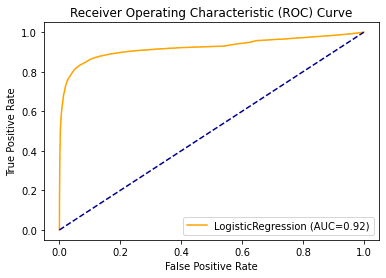

In [51]:
# calculate and draw roc curve
fper, tper, thresholds = roc_curve(test_edge_labels, test_preds) 
plt.figure()
plt.plot(fper, tper, color='orange', label=f'LogisticRegression (AUC={test_roc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.savefig("figures/roc_curve.png")

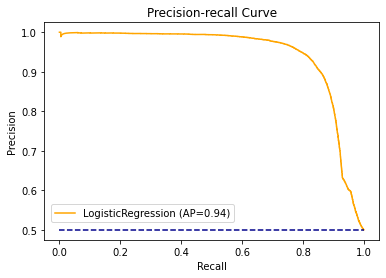

In [52]:
# calculate and draw precision-recall curve
precision, recall, thresholds = precision_recall_curve(test_edge_labels, test_preds) 
area_pr = auc(recall, precision)
no_skill = len(test_edge_labels[test_edge_labels==1]) / len(test_edge_labels)
plt.figure()
plt.plot(recall, precision, color='orange', label=f'LogisticRegression (AP={area_pr:.2f})')
ax = plt.gca()
ax.legend(loc=(0.02, 0.08))
plt.plot([0, 1], [no_skill, no_skill], color='darkblue', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-recall Curve')
plt.savefig("figures/pr_curve.png")

#### 6. Node embeddings generation with tuned hyper-parameters on all edges with node2vec

In [53]:
# Generate walks and train node2vec model on all edges of all graphs
for graph_name in graphs_dict.keys():
    g = graphs_dict[graph_name] 
    node2vec = Node2Vec(g, dimensions=dimensions, walk_length=walk_length, num_walks=num_walks, workers=workers, p=p, q=q)
    model = node2vec.fit(window=window, min_count=1, batch_words=4)
    model.save(f'results/node2vec_{graph_name}.model')
    model.wv.save_word2vec_format(f'results/node2vec_{graph_name}.embeddings')

Generating walks (CPU: 1): 100%|██████████| 10/10 [08:17<00:00, 49.75s/it]
